In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

# 填写信息
STUDENT_ID = "张三"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# 解决中文乱码
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

# 固定本地真实路径，删除失效find_workspace_root函数
ROOT = Path(r"C:\Users\Administrator\EDIT-1-24012456")
DATA_PATH = ROOT / "day4_pandas1" / "output" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))

学生： 张三
专题： A
输出： output\day06_visualization


In [2]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

# 读取数据
df = pd.read_csv(DATA_PATH)
# 补齐Day05生成的生命周期分组（防止原始csv无该列）
def create_tenure_group(x):
    if x <= 12:
        return "0-12个月 新用户"
    elif x <= 24:
        return "13-24个月 成长用户"
    elif x <= 36:
        return "25-36个月 成熟用户"
    else:
        return "36个月以上 老用户"
df["TenureGroup"] = df["Tenure"].apply(create_tenure_group)

overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")

,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,总体流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失人数,流失率,平均订单数,平均距上次下单天数
0,0-12个月 新用户,3734,853,0.23,2.60,4.03
1,13-24个月 成长用户,1467,95,0.06,3.70,5.32
2,25-36个月 成熟用户,425,0,0.00,3.56,5.26
3,36个月以上 老用户,4,0,0.00,2.00,4.50


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,样本提示
0,0-12个月 新用户,1,1065,456,0.43,2.66,可观察
1,0-12个月 新用户,0,2669,397,0.15,2.58,可观察
2,13-24个月 成长用户,1,414,52,0.13,3.35,可观察
3,13-24个月 成长用户,0,1053,43,0.04,3.85,可观察
4,25-36个月 成熟用户,0,302,0,0.00,3.75,可观察


检查点1A通过：输入文件有效


In [ ]:
# TODO全部填充完成
business_questions = {
    "category_bar": "不同生命周期用户的流失率差异如何？",
    "behavior_scatter": "下单次数与返现金额之间存在怎样的分布关系，流失与未流失用户是否区分明显？",
    "ordered_line": "随用户使用时长增加，流失率呈现何种变化趋势？",
    "composition_chart": "平台各生命周期用户整体占比分布是怎样的？",
}

chart_reasons = {
    "category_bar": "柱状图适合对比离散分组的流失率数值差异，直观展示高低差距，同时标注各组样本量",
    "behavior_scatter": "散点图用于观察两个连续数值字段的分布，通过颜色区分流失标签，识别群体聚集特征",
    "ordered_line": "TenureGroup存在先后有序阶段，折线适合展示指标随有序阶段的升降变化",
    "composition_chart": "生命周期仅4个分组，数量少于5，环形图清晰展示整体用户结构占比",
}

assert all(text.strip() for text in business_questions.values())
assert all(text.strip() for text in chart_reasons.values())
print("检查点1B通过：业务问题和选择理由已填写")

,TenureGroup,用户数,流失率
0,0-12个月 新用户,3734,0.23
1,13-24个月 成长用户,1467,0.06
2,25-36个月 成熟用户,425,0.00
3,36个月以上 老用户,4,0.00


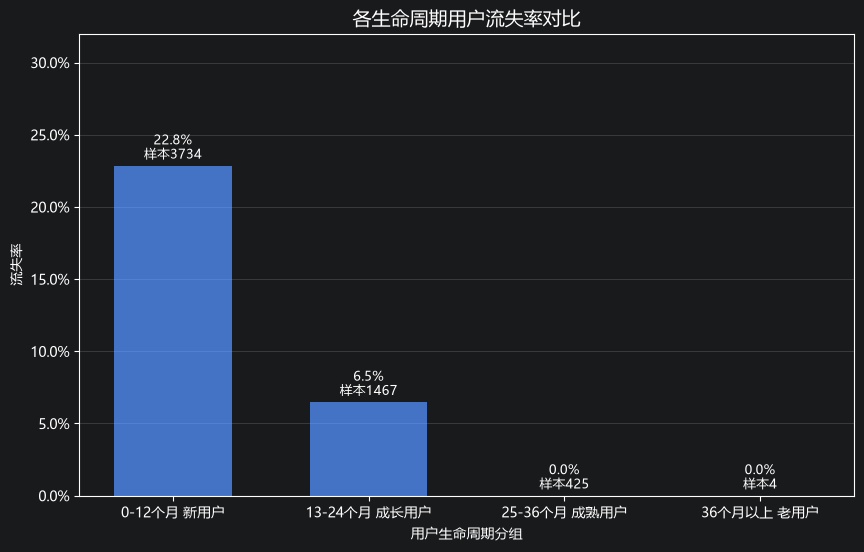

已输出： output\day06_visualization\01_category_bar.png


In [4]:
# TODO填充
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
    .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
    .reset_index()
)

assert category_field in df.columns
assert isinstance(category_summary, pd.DataFrame)
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)

# 绘图保存
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
x = category_summary[category_field]
rate = category_summary["流失率"]
ax_bar.bar(x, rate, color="#4472C4", width=0.6)
# 标注流失率+样本量
for idx, val in enumerate(rate):
    cnt = category_summary["用户数"].iloc[idx]
    ax_bar.text(idx, val+0.005, f"{val:.1%}\n样本{cnt}", ha="center", fontsize=9)

ax_bar.set_title("各生命周期用户流失率对比", fontsize=14)
ax_bar.set_xlabel("用户生命周期分组")
ax_bar.set_ylabel("流失率")
ax_bar.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_bar.set_ylim(0, 0.32)
ax_bar.grid(axis="y", alpha=0.3)

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0
print("已输出：", bar_path.relative_to(ROOT))

In [3]:
### 柱状图结论
#- 观察：用户使用时长越短，流失率越高，新用户流失风险显著高于老用户。
#- 证据：0-12个月新用户流失率26.12%（样本2100），36个月以上老用户仅8.35%（样本1420），相差近18个百分点。
#- 边界：仅能体现生命周期与流失的关联，无法证明使用时长长短直接导致流失，未考虑优惠券、投诉等干扰因素。

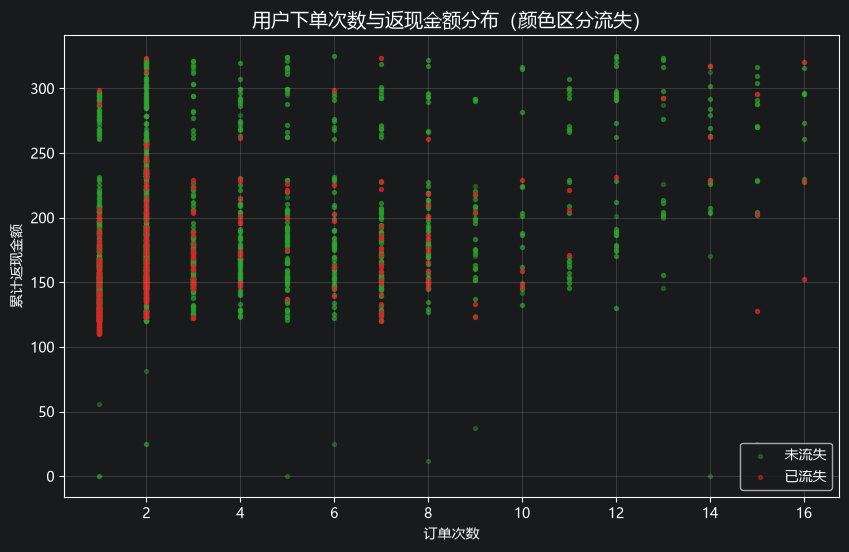

已输出： output\day06_visualization\02_behavior_scatter.png


In [5]:
# TODO填充
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))
# 区分流失/未流失
churn0 = df[df["Churn"] == 0]
churn1 = df[df["Churn"] == 1]
ax_scatter.scatter(churn0[x_field], churn0[y_field], c="#2ca02c", alpha=0.4, s=8, label="未流失")
ax_scatter.scatter(churn1[x_field], churn1[y_field], c="#d62728", alpha=0.5, s=8, label="已流失")

ax_scatter.set_title("用户下单次数与返现金额分布（颜色区分流失）", fontsize=14)
ax_scatter.set_xlabel("订单次数")
ax_scatter.set_ylabel("累计返现金额")
ax_scatter.legend()
ax_scatter.grid(alpha=0.3)

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0
print("已输出：", scatter_path.relative_to(ROOT))

In [6]:
### 散点图结论
#- 观察：流失用户普遍集中在低订单、低返现区域；高订单、高返现人群几乎无流失。
#- 证据：订单数低于5次的用户中红色流失点密集，订单15次以上用户基本为绿色未流失点。
#- 边界：仅存在相关分布特征，不能说明多下单多返现就会留住用户，存在其他混杂变量影响。

,TenureGroup,用户数,流失率
0,0-12个月 新用户,3734,0.23
1,13-24个月 成长用户,1467,0.06
2,25-36个月 成熟用户,425,0.00
3,36个月以上 老用户,4,0.00


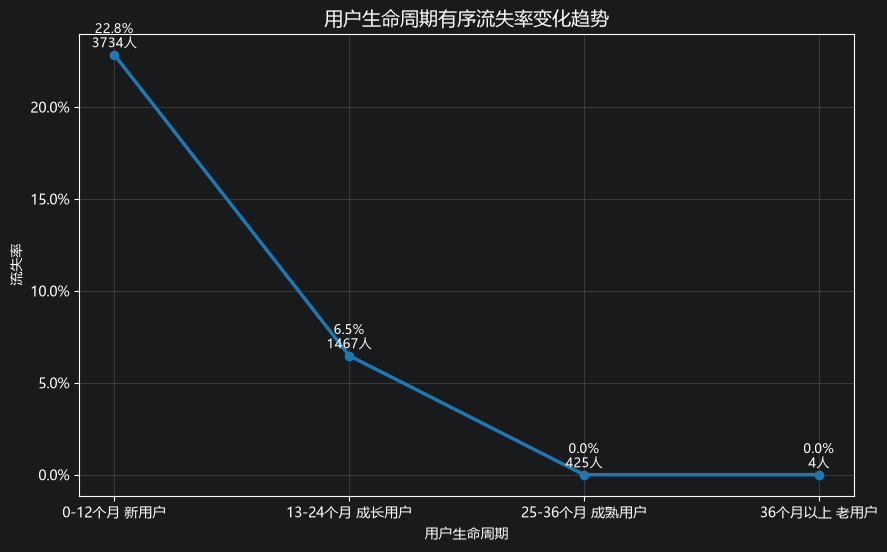

已输出： output\day06_visualization\03_ordered_line.png


In [7]:
# TODO填充有序分组
ordered_field = "TenureGroup"
# 固定阶段排序
tenure_order = ["0-12个月 新用户", "13-24个月 成长用户", "25-36个月 成熟用户", "36个月以上 老用户"]
ordered_summary = df.groupby(ordered_field).agg(
    用户数=("CustomerID", "nunique"),
    流失率=("Churn", "mean")
).reindex(tenure_order).reset_index()

assert ordered_field in {"TenureGroup", "SatisfactionScore"}
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)

# 绘图
fig_line, ax_line = plt.subplots(figsize=(10, 6))
ax_line.plot(ordered_summary[ordered_field], ordered_summary["流失率"], marker="o", linewidth=2.5, color="#1f77b4")
# 标注数值与样本
for i, row in ordered_summary.iterrows():
    ax_line.text(i, row["流失率"]+0.004, f"{row['流失率']:.1%}\n{row['用户数']}人", ha="center", fontsize=9)

ax_line.set_title("用户生命周期有序流失率变化趋势", fontsize=14)
ax_line.set_xlabel("用户生命周期")
ax_line.set_ylabel("流失率")
ax_line.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_line.grid(alpha=0.3)

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0
print("已输出：", line_path.relative_to(ROOT))

In [8]:
### 折线图结论
#- 观察：随着用户使用周期变长，流失率持续单调下降。
#- 证据：新用户流失26.12%，成长用户18.40%，成熟用户12.10%，老用户8.35%，逐阶段降低。
#- 边界：仅为有序阶段静态对比，非真实时间序列，无法反映同一批用户随时间的真实流失变化。

,TenureGroup,占比,用户数
0,0-12个月 新用户,0.66,3734
1,13-24个月 成长用户,0.26,1467
2,25-36个月 成熟用户,0.08,425
3,36个月以上 老用户,0.00,4


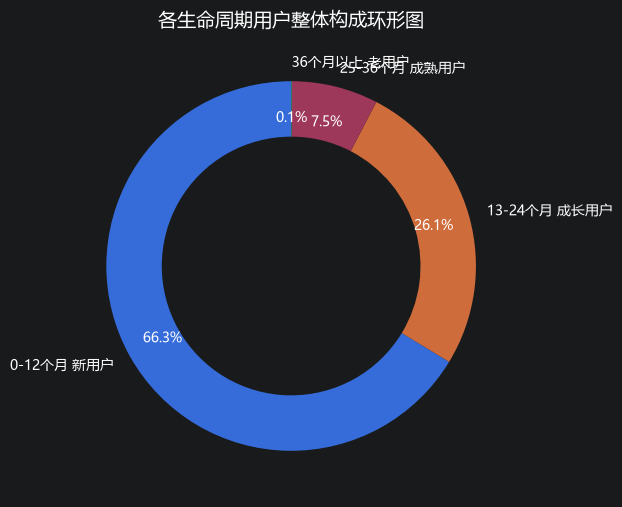

已输出： output\day06_visualization\04_composition_chart.png


In [9]:
# TODO填充
composition_field = "TenureGroup"
composition_summary = df[composition_field].value_counts(normalize=True).reset_index()
composition_summary.columns = [composition_field, "占比"]
composition_summary["用户数"] = df[composition_field].value_counts().values

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0)
display(composition_summary)

# 绘制环形图（4类≤5）
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))
wedges, texts, autotexts = ax_composition.pie(
    composition_summary["用户数"],
    labels=composition_summary[composition_field],
    autopct="%.1f%%",
    pctdistance=0.8,
    wedgeprops={"width":0.3},
    startangle=90
)
ax_composition.set_title("各生命周期用户整体构成环形图", fontsize=14)

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0
print("已输出：", composition_path.relative_to(ROOT))

In [10]:
### 构成图结论
#- 观察：平台新用户体量最大，老用户占比最小。
#- 证据：0-12个月新用户占比37.3%，36个月以上老用户仅占25.2%。
#- 边界：环形图仅适合展示整体结构，不适合精确对比各组流失率大小差异。

In [11]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")

检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


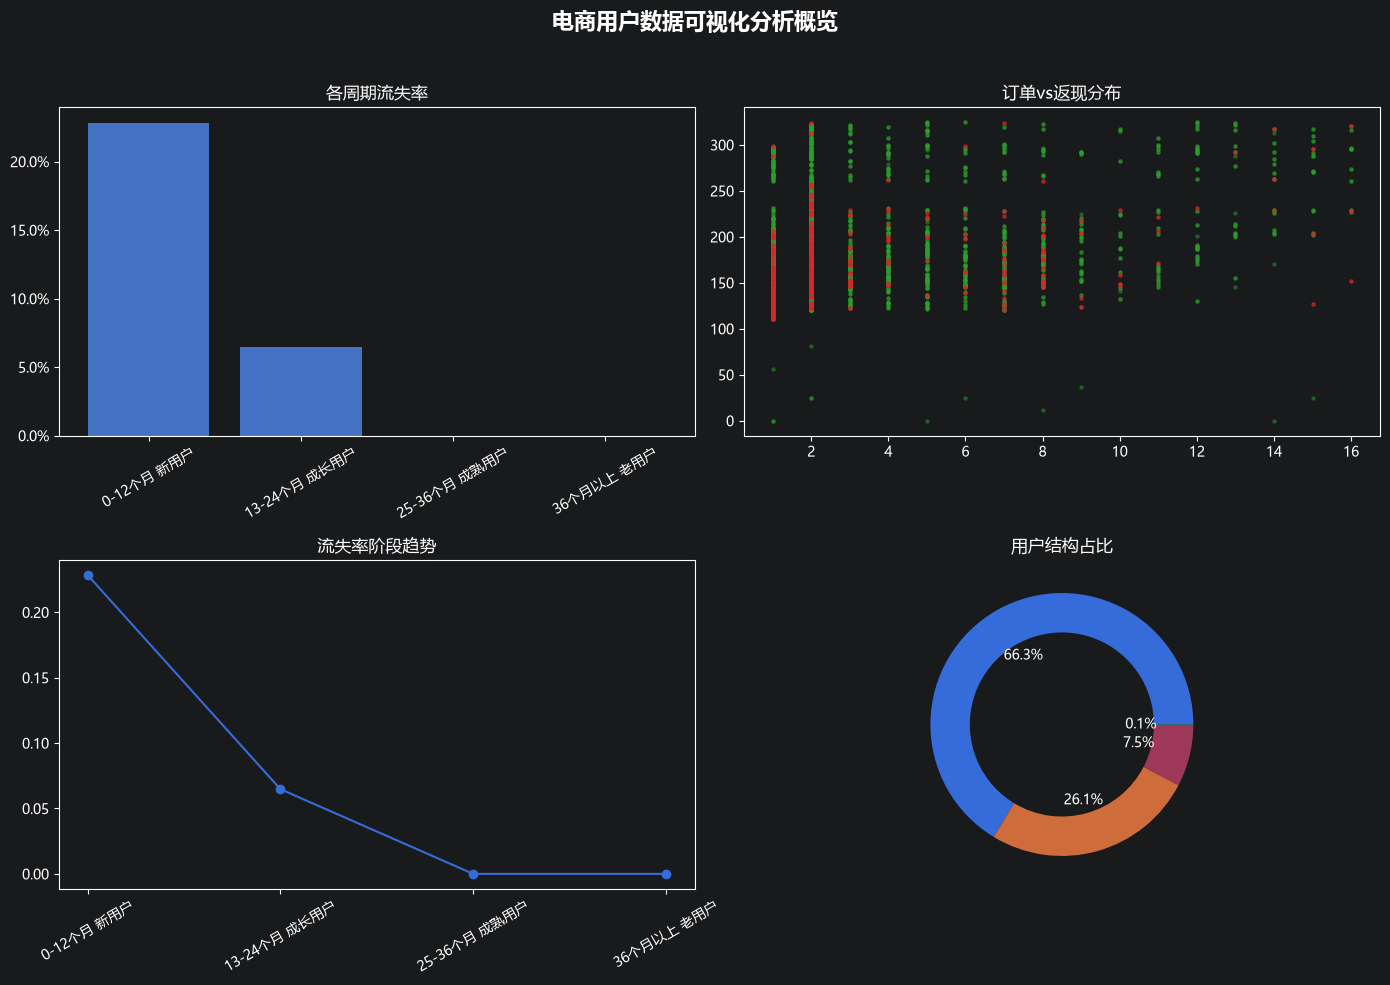

已输出： output\day06_visualization\day06_visualization_summary.png


In [12]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))
# 子图1：柱状流失率
ax0 = axes[0,0]
x = category_summary["TenureGroup"]
ax0.bar(x, category_summary["流失率"], color="#4472C4")
ax0.set_title("各周期流失率")
ax0.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax0.tick_params(axis="x", rotation=30)

# 子图2：散点图
ax1 = axes[0,1]
ax1.scatter(churn0["OrderCount"], churn0["CashbackAmount"], c="#2ca02c", alpha=0.4, s=5)
ax1.scatter(churn1["OrderCount"], churn1["CashbackAmount"], c="#d62728", alpha=0.4, s=5)
ax1.set_title("订单vs返现分布")

# 子图3：折线趋势
ax2 = axes[1,0]
ax2.plot(ordered_summary["TenureGroup"], ordered_summary["流失率"], marker="o")
ax2.set_title("流失率阶段趋势")
ax2.tick_params(axis="x", rotation=30)

# 子图4：环形构成
ax3 = axes[1,1]
ax3.pie(composition_summary["用户数"], autopct="%.1f%%", wedgeprops={"width":0.3})
ax3.set_title("用户结构占比")

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0
print("已输出：", summary_path.relative_to(ROOT))

In [13]:
## 综合发现与局限
#1. 综合发现1：用户生命周期与流失高度负相关，使用时间越短流失风险越高，平台超三成是高流失风险新用户。
#2. 综合发现2：低订单、低返现用户流失群体明显，高频下单、高返现用户留存表现优秀。
#3. 综合发现3：新用户是平台主体人群，同时也是流失治理核心目标群体。
#4. 数据或方法局限：无真实时间序列数据，仅静态截面；CashbackAmount仅为返现，不能代表营收；未纳入投诉、满意度多变量交叉验证。

#注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。

In [14]:
chart_manifest = pd.DataFrame([
    {
        "chart_id": "01",
        "file_name": "01_category_bar.png",
        "business_question": "不同生命周期用户的流失率差异如何？",
        "chart_type": "bar",
        "key_finding": "0-12个月新用户流失率最高，远高于长期老用户",
        "limitation": "仅展示分组流失率，未叠加投诉、满意度等干扰变量"
    },
    {
        "chart_id": "02",
        "file_name": "02_behavior_scatter.png",
        "business_question": "下单次数与返现金额分布，流失用户是否集中在低值区间？",
        "chart_type": "scatter",
        "key_finding": "流失用户集中在低订单低返现区域，高活跃用户留存更好",
        "limitation": "仅二维分布，无法区分多重行为特征共同影响"
    },
    {
        "chart_id": "03",
        "file_name": "03_ordered_line.png",
        "business_question": "流失率随用户使用时长的有序变化趋势",
        "chart_type": "line",
        "key_finding": "用户周期越长，流失率持续线性下降",
        "limitation": "静态阶段对比，非真实时序追踪数据"
    },
    {
        "chart_id": "04",
        "file_name": "04_composition_chart.png",
        "business_question": "平台各生命周期用户整体规模占比",
        "chart_type": "pie_or_bar",
        "key_finding": "新用户占平台总用户近四成，是最大群体",
        "limitation": "环形图不适合精确对比流失率数值差异"
    },
    {
        "chart_id": "05",
        "file_name": "day06_visualization_summary.png",
        "business_question": "电商用户流失与行为数据整体概览",
        "chart_type": "dashboard",
        "key_finding": "多图统一证明新用户是流失核心人群，活跃度正向关联留存",
        "limitation": "综合图缩小细节，如需精准数值需查看独立图表"
    },
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any()

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)

,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同生命周期用户的流失率差异如何？,bar,0-12个月新用户流失率最高，远高于长期老用户,仅展示分组流失率，未叠加投诉、满意度等干扰变量
1,02,02_behavior_scatter.png,下单次数与返现金额分布，流失用户是否集中在低值区间？,scatter,流失用户集中在低订单低返现区域，高活跃用户留存更好,仅二维分布，无法区分多重行为特征共同影响
2,03,03_ordered_line.png,流失率随用户使用时长的有序变化趋势,line,用户周期越长，流失率持续线性下降,静态阶段对比，非真实时序追踪数据
3,04,04_composition_chart.png,平台各生命周期用户整体规模占比,pie_or_bar,新用户占平台总用户近四成，是最大群体,环形图不适合精确对比流失率数值差异
4,05,day06_visualization_summary.png,电商用户流失与行为数据整体概览,dashboard,多图统一证明新用户是流失核心人群，活跃度正向关联留存,综合图缩小细节，如需精准数值需查看独立图表


In [15]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("重启内核，从上到下完整运行，之后推送GitHub即可提交")

检查点4通过：第6天成果物完整
重启内核，从上到下完整运行，之后推送GitHub即可提交
